# NB03: Lexical Analysis

## Language Processing

## LEI/2025-26

#### Nuno Macedo
Universidade do Minho



# 3.1 Lexical Analysis

- Lexical analysis is the first step of the language processing pipeline

- A lexical analyzer (or a *lexer*) converts a sequence of symbols (input text) into a sequence of *tokens*, contiguous sequences of symbols that are assigned a "type"

- It may also discard some syntactically irrelevant symbols (such as spacing)

- This is the only phase that processes the input at the character level
  - It must be very efficient (based on regular languages)
  - Stores traceability information for error messages (line, column)

  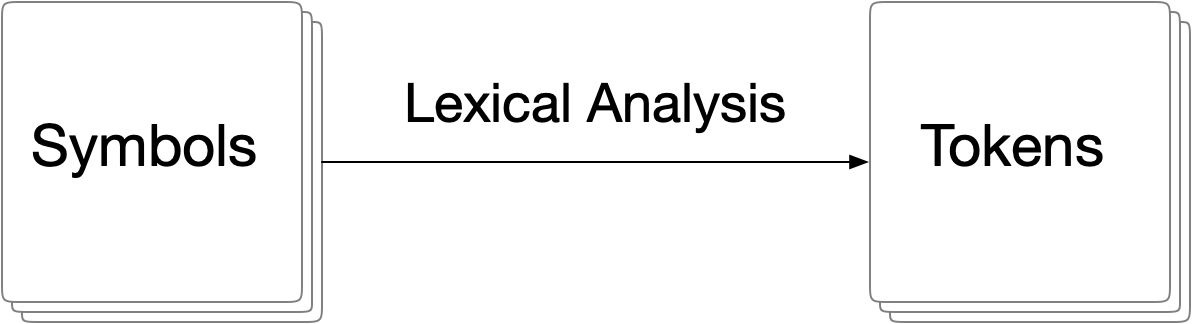

## Tokens

- A *token* is the fundamental unit in the syntactic analysis (next phase of the pipeline)

- Each token has:
  - A token *name*, that denotes its category
  - An optional *attribute* (or *value*) that stores additional information

- Operators and keywords usually have a fixed *lexeme*

- But others (e.g., identifiers or integer literals) do not, they are variable tokens
  - Their shape is defined by a pattern (regular expression)
  - The *lexeme* associated with a token is stored as an attribute

- Another typical attribute is the lexeme position in the original text, useful for error reporting and debugging

## ✏️ Tokenization Example: Heterogenous lists

```
[ John, 10, 20, Jane, 30, 40 ]
```

- Here there are 5 token categories:
  - delimiters `LPAREN`, `RPAREN` and `COMMA`
  - variable tokens `IDEN` and `INT`

- Result of the tokenization:

  ```
  LPAREN, IDEN(John), COMMA, INT(10), COMMA, INT(20), IDEN(Jane), COMMA, INT(30), COMMA, INT(40), RPAREN
  ```

- Only variable tokens need to store the lexeme

- Spaces have been removed in the process



## ✏️ Tokenization Example: Shopping lists with categories

```
* Produce
Apples (or pears)
Potatoes
* Bakery
Bread (*the good kind)
Muffins
```

- Here there are 2 token categories:
  - `HEADER` and `TEXT`, both variable

- Result of the tokenization:

  ```
  HEADER(Produce), TEXT(Apples (or pears)), TEXT(Potatoes), HEADER(Bakery), TEXT(Bread (*the good kind)), TEXT(Muffins)
  ```
- New lines have been removed in the process, but not spaces


## ✏️ Tokenization Example: Arithmetic expressions

```
let x = 5;
let y = 10;
10 * (x + 4) / y
```

- Here there are 11 token categories:
  - keyword `LET`
  - delimiters `LPAREN`, `RPAREN` and `SCOLON`
  - operators `ADD`, `SUB`, `MUL`, `DIV` and `EQ`
  - variable tokens `IDEN` and `INT`

- Result of the tokenization:

  ```
  LET, IDEN(x), EQ, INT(5), SCOLON, LET, IDEN(y), EQ, INT(10), SCOLON, IN(10), MUL, LPAREN, IDEN(x), ADD, INT(4), DIV, IDEN(y)
  ```

- Only variable tokens store the lexeme

- Spaces and new lines have been removed in the process



⚠️ There are many different ways to tokenize the same text, and this decision affects the syntactic analysis phase that follows. For instance, we could have a single token category `OP` for operators, and store the concrete operator as an attribute.

# 3.2 Token Recognition

## Token patterns

- Since not all tokens have fixed lexemes, we need a mechanism to define the pattern that defines each token

- This must be a very efficient process, to process input texts with thousands of symbols

- This is where *regular expressions* come in, as a way to define and efficiently recognize lexemes

- A token category is described by a regular expression

- We have already seen regular expressions to recognize identifiers, integer numbers, floating point numbers, or string literals

## From token patterns to token recognition

- Token patterns describe the set of valid character sequences for each token kind

- During lexical analysis, the input is processed from left to right, and tokens are recognized incrementally

- Once a token category is selected, characters are consumed as long as the current prefix is compatible with the corresponding pattern

- The token is completed as soon as reading one more character would make it invalid

## Building the master regular expression

- In general, a lexer uses a "master" regular expression built from the alternative of the patterns for each token type

- Different token categories may accept the same character sequences, a recognized lexeme may correspond to more than one token category

- Typical case: reserved keywords that are also valid identifiers
  - In the example above, lexeme `let` is classified as the a keyword token `LET`, but also matches the identifier token `IDEN`

- The lexer must apply a consistent classification policy when assigning a token category to a recognized lexeme

## Building a lexical analyzer

- Besides the tokens that will be fed to the syntactic analysis phase, we also need to identify tokens that will be discarded (e.g., spacing or comments)

- We can create a simple lexical analyser by using a regular expression processor and named capturing groups to distinguish the token names

- Then we iterate over every match, and identify which group captured the lexeme

In [ ]:
import re

### ✏️ Handwritten lexer example: Heterogenous lists

In [ ]:
def tokenize(text):
  regex = r"(?P<INT>\d+)|(?P<IDEN>\w+)|(?P<LPAREN>\[)|(?P<RPAREN>\])|(?P<COMMA>,)|(?P<IGNORE>\s+)"
  recognized = []
  for mtch in re.finditer(regex,text):
    if mtch.groupdict()['IDEN']:
      token = ("IDEN", mtch.groupdict()['IDEN'], mtch.span())
    elif mtch.groupdict()['INT']:
      token = ("INT", mtch.groupdict()['INT'], mtch.span())
    elif mtch.groupdict()['COMMA']:
      token = ("COMMA", mtch.span())
    elif mtch.groupdict()['LPAREN']:
      token = ("LPAREN", mtch.span())
    elif mtch.groupdict()['RPAREN']:
      token = ("RPAREN", mtch.span())
    elif mtch.groupdict()['IGNORE']:
      token = ("IGNORE", mtch.span())
    if token[0] != "IGNORE":
      recognized.append(token)
  return recognized

text = "[ John, 10, 20, Jane, 30, 40 ]"
tokens = tokenize(text)
print("\n".join(str(t) for t in tokens))

('LPAREN', (0, 1))
('IDEN', 'John', (2, 6))
('COMMA', (6, 7))
('INT', '10', (8, 10))
('COMMA', (10, 11))
('INT', '20', (12, 14))
('COMMA', (14, 15))
('IDEN', 'Jane', (16, 20))
('COMMA', (20, 21))
('INT', '30', (22, 24))
('COMMA', (24, 25))
('INT', '40', (26, 28))
('RPAREN', (29, 30))


### Traceability

- For traceability purposes, lexical analysis must keep track of the position of each token in the input

- Typically achieved by maintaining line and column counters while scanning the character stream
  - Newlines are always recognized by the lexer, even when they are not emitted as tokens
  - The same applies to spacing symbols
  
- Note, however, that some languages give a syntactic role to spacing and newlines (e.g., Python)
  - In these cases, they become part of the token stream


### ✏️ Handwritten lexer example: Shopping lists with categories

In [ ]:
def tokenize(text):
  regex = r"(?P<HEADER>\*\s+([^\n]*))|(?P<TEXT>[^\n]+)|(?P<IGNORE>\n+)"
  recognized = []
  for i, line in enumerate(text):
    # order matters, HEADER lexemes also match the TEXT pattern
    for mtch in re.finditer(regex,line):
      if mtch.groupdict()['HEADER']:
        token = ("HEADER", mtch.group(2), i, mtch.span())
      elif mtch.groupdict()['TEXT'] != None:
        token = ("TEXT", mtch.groupdict()['TEXT'], i, mtch.span())
      elif mtch.groupdict()['IGNORE']:
        token = ("IGNORE", i, mtch.span())
      if token[0] != "IGNORE":
        recognized.append(token)
  return recognized

text = """* Produce
Apples (or pears)
Potatoes
* Bakery
Bread (*the good kind)
Muffins"""
tokens = tokenize(text.splitlines())
print("\n".join(str(t) for t in tokens))

('HEADER', 'Produce', 0, (0, 9))
('TEXT', 'Apples (or pears)', 1, (0, 17))
('TEXT', 'Potatoes', 2, (0, 8))
('HEADER', 'Bakery', 3, (0, 8))
('TEXT', 'Bread (*the good kind)', 4, (0, 22))
('TEXT', 'Muffins', 5, (0, 7))


### Lexical errors

- Some errors are lexical, and can be identified during lexical analysis before the syntactic analysis begins

- Typical lexical errors include:
  - Invalid symbols
  - Unterminated string literal (`"hello`)
  - Malformed number (`12.3.4`)

- Many ways to handle them:
  - Immediatly throw an error
  - Register the error, but proceed with the tokenization
    - Then fail, or let the parser handle error tokens in the next phase

### ✏️ Handwritten lexer example: Arithmetic expressions

In [ ]:
def tokenize(text):
  regex = r"(?P<LET>let)|(?P<INT>\d+)|(?P<IDEN>\w+)|(?P<ADD>\+)|(?P<SUB>-)|(?P<MUL>\*)|(?P<DIV>/)|(?P<LPAREN>\()|(?P<RPAREN>\))|(?P<EQ>=)|(?P<SCOLON>;)|(?P<IGNORE>\s+)|(?P<UNKNOWN>.)"
  recognized = []
  errors = []
  for i, line in enumerate(text):
    for mtch in re.finditer(regex,line):
      if mtch.groupdict()['LET']:
        token = ("LET", i, mtch.span())
      elif mtch.groupdict()['IDEN']:
        token = ("IDEN", i, mtch.groupdict()['IDEN'], mtch.span())
      elif mtch.groupdict()['INT']:
        token = ("INT", i, mtch.groupdict()['INT'], mtch.span())
      elif mtch.groupdict()['ADD']:
        token = ("ADD", i, mtch.span())
      elif mtch.groupdict()['SUB']:
        token = ("SUB", i, mtch.span())
      elif mtch.groupdict()['MUL']:
        token = ("MUL", i, mtch.span())
      elif mtch.groupdict()['DIV']:
        token = ("DIV", i, mtch.span())
      elif mtch.groupdict()['EQ']:
        token = ("EQ", i, mtch.span())
      elif mtch.groupdict()['LPAREN']:
        token = ("LPAREN", i, mtch.span())
      elif mtch.groupdict()['RPAREN']:
        token = ("RPAREN", i, mtch.span())
      elif mtch.groupdict()['SCOLON']:
        token = ("SCOLON", i, mtch.span())
      elif mtch.groupdict()['IGNORE']:
        token = ("IGNORE", i, mtch.span())
      elif mtch.groupdict()['UNKNOWN']:
        token = ("UNKNOWN", mtch.groupdict()['UNKNOWN'], i, mtch.span())
      if token[0] != "IGNORE":
        if token[0] == "UNKNOWN":
          errors.append(token)
        else:
          recognized.append(token)
  return recognized, errors

In [ ]:
text = """let x = 5;
let y = 10;
10 * (x + 4) / y"""
tokens, errors = tokenize(text.splitlines())
if errors:
  print("* ERRORS")
  print("\n".join(str(t) for t in errors))
print("* TOKENS")
print("\n".join(str(t) for t in tokens))


* TOKENS
('LET', 0, (0, 3))
('IDEN', 0, 'x', (4, 5))
('EQ', 0, (6, 7))
('INT', 0, '5', (8, 9))
('SCOLON', 0, (9, 10))
('LET', 1, (0, 3))
('IDEN', 1, 'y', (4, 5))
('EQ', 1, (6, 7))
('INT', 1, '10', (8, 10))
('SCOLON', 1, (10, 11))
('INT', 2, '10', (0, 2))
('MUL', 2, (3, 4))
('LPAREN', 2, (5, 6))
('IDEN', 2, 'x', (6, 7))
('ADD', 2, (8, 9))
('INT', 2, '4', (10, 11))
('RPAREN', 2, (11, 12))
('DIV', 2, (13, 14))
('IDEN', 2, 'y', (15, 16))


In [ ]:
text = """let x = 5;
let y = 10;
10 * (x + 4) % y"""
tokens, errors = tokenize(text.splitlines())
if errors:
  print("* ERRORS")
  print("\n".join(str(t) for t in errors))
print("* TOKENS")
print("\n".join(str(t) for t in tokens))

* ERRORS
('UNKNOWN', '%', 2, (13, 14))
* TOKENS
('LET', 0, (0, 3))
('IDEN', 0, 'x', (4, 5))
('EQ', 0, (6, 7))
('INT', 0, '5', (8, 9))
('SCOLON', 0, (9, 10))
('LET', 1, (0, 3))
('IDEN', 1, 'y', (4, 5))
('EQ', 1, (6, 7))
('INT', 1, '10', (8, 10))
('SCOLON', 1, (10, 11))
('INT', 2, '10', (0, 2))
('MUL', 2, (3, 4))
('LPAREN', 2, (5, 6))
('IDEN', 2, 'x', (6, 7))
('ADD', 2, (8, 9))
('INT', 2, '4', (10, 11))
('RPAREN', 2, (11, 12))
('IDEN', 2, 'y', (15, 16))


## Generalizing the lexical analysis

- A lexer follows a common high-level organization, independently of the language being processed

- For a given language, we need to identify:
  - the token kinds
  - the patterns describing valid lexemes for each category

- From these, a *lexer generator* can generate a lexer for the language

- We assume a special token name (`IGNORE`) for symbols to be ignored

- When a lexeme is compatible with multiple categories, the lexer must apply a consistent convention
  - For now, we assume the convention is based on the order in which token categories are defined

- In practice, other aspects are often handled by lexers, which we will ignore for now:
  - distinguishing between fixed and variable tokens
  - customizing the information stored for each token

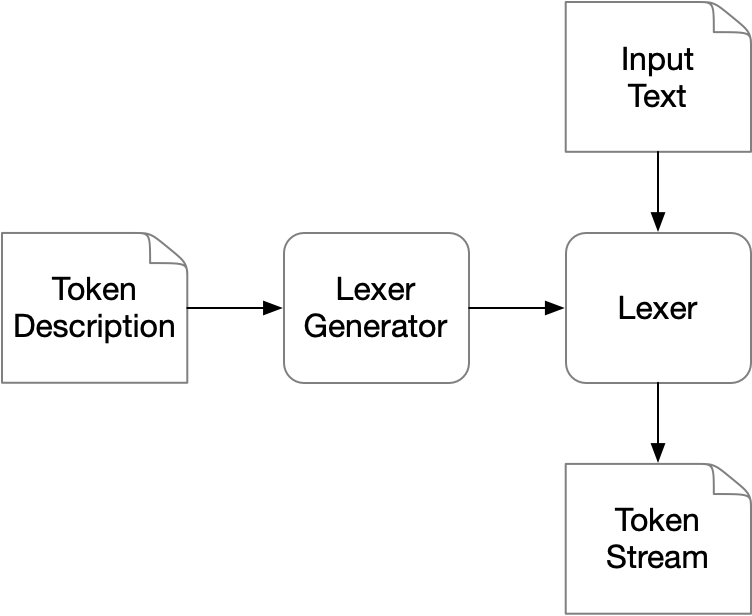

### First version: a parametrizable lexer

- Let us provide the lexer with a dictionary of tokens, and generate the master pattern from it


In [ ]:
def tokenize(token_dict, text):
  regex = ("|".join(f"(?P<{token}>{pattern})" for token, pattern in token_dict.items()))+"|(?P<UNKNOWN>.)"
  errors = []
  recognized = []
  for i, line in enumerate(text):
    for mtch in re.finditer(regex,line):
      for k,v in mtch.groupdict().items():
        if v != None:
          token = (k, v, i, mtch.span())
          break

      if token[0] != "IGNORE":
        if token[0] == "UNKNOWN":
          errors.append(token)
        else:
          recognized.append(token)
  return recognized, errors

In [ ]:
def process(tokens, text):
  tokens, errors = tokenize(tokens, text.splitlines())
  if errors:
    print("* ERRORS")
    print("\n".join(str(t) for t in errors))
  print("* TOKENS")
  print("\n".join(str(t) for t in tokens))

### ✏️ Lexer generator example: Heterogenous lists

In [ ]:
tokens = {
    "INT": r"\d+",
    "IDEN": r"\w+",
    "LPAREN": r"\[",
    "RPAREN": r"\]",
    "COMMA": r",",
    "IGNORE": r"\s+"
}

text = "[ John, 10, 20, Jane, 30, 40 ]"

process(tokens, text)

* TOKENS
('LPAREN', '[', 0, (0, 1))
('IDEN', 'John', 0, (2, 6))
('COMMA', ',', 0, (6, 7))
('INT', '10', 0, (8, 10))
('COMMA', ',', 0, (10, 11))
('INT', '20', 0, (12, 14))
('COMMA', ',', 0, (14, 15))
('IDEN', 'Jane', 0, (16, 20))
('COMMA', ',', 0, (20, 21))
('INT', '30', 0, (22, 24))
('COMMA', ',', 0, (24, 25))
('INT', '40', 0, (26, 28))
('RPAREN', ']', 0, (29, 30))


### ✏️ Lexer generator example: Arithmetic expressions

In [ ]:
tokens = {
    "LET": r"let",
    "INT": r"\d+",
    "IDEN": r"\w+",
    "LPAREN": r"\(",
    "RPAREN": r"\)",
    "EQ": r"=",
    "SCOLON": r";",
    "ADD": r"\+",
    "SUB": r"-",
    "MUL": r"\*",
    "DIV": r"/",
    "IGNORE": r"\s+"
}

text = """let x = 5;
let y = 10;
10 * (x + 4) % y"""

process(tokens, text)

* ERRORS
('UNKNOWN', '%', 2, (13, 14))
* TOKENS
('LET', 'let', 0, (0, 3))
('IDEN', 'x', 0, (4, 5))
('EQ', '=', 0, (6, 7))
('INT', '5', 0, (8, 9))
('SCOLON', ';', 0, (9, 10))
('LET', 'let', 1, (0, 3))
('IDEN', 'y', 1, (4, 5))
('EQ', '=', 1, (6, 7))
('INT', '10', 1, (8, 10))
('SCOLON', ';', 1, (10, 11))
('INT', '10', 2, (0, 2))
('MUL', '*', 2, (3, 4))
('LPAREN', '(', 2, (5, 6))
('IDEN', 'x', 2, (6, 7))
('ADD', '+', 2, (8, 9))
('INT', '4', 2, (10, 11))
('RPAREN', ')', 2, (11, 12))
('IDEN', 'y', 2, (15, 16))


### Second version: a proper, standalone lexer generator

- To promote performance and modularity, lexers are usually standalone programs

- Let us generate a lexer from a dictionary of tokens


In [ ]:
def generator(token_dict):

  regex = ("|".join(f"(?P<{token}>{pattern})" for token, pattern in token_dict.items()))+"|(?P<UNKNOWN>.)"
  code = f"""import re
def tokenize(text):
  errors = []
  recognized = []
  for i, line in enumerate(text):
    for mtch in re.finditer(r"{regex}",line):
      for k,v in mtch.groupdict().items():
        if v != None:
          token = (k, v, i, mtch.span())

      if token[0] != "IGNORE":
        if token[0] == "UNKNOWN":
          errors.append(token)
        else:
          recognized.append(token)
  return recognized, errors"""
  print(code)

### ✏️ Lexer generator example: Heterogenous lists

In [ ]:
generator({
    "INT": r"\d+",
    "IDEN": r"\w+",
    "LPAREN": r"\[",
    "RPAREN": r"\]",
    "COMMA": r",",
    "IGNORE": r"\s+"
})

import re
def tokenize(text):
  errors = []
  recognized = []
  for i, line in enumerate(text):
    for mtch in re.finditer(r"(?P<INT>\d+)|(?P<IDEN>\w+)|(?P<LPAREN>\[)|(?P<RPAREN>\])|(?P<COMMA>,)|(?P<IGNORE>\s+)|(?P<UNKNOWN>.)",line):
      for k,v in mtch.groupdict().items():
        if v != None:
          token = (k, v, i, mtch.span())

      if token[0] != "IGNORE":
        if token[0] == "UNKNOWN":
          errors.append(token)
        else:
          recognized.append(token)
  return recognized, errors


### Third version: proper IO

  - The lexer generator will consume JSON files with token defnitions

  - The generated lexers will process text from the standard input

In [ ]:
import json

def generator(token_file):
  with open(token_file, "r") as f:
    token_dict = json.load(f)

  regex = ("|".join(f"(?P<{token}>{pattern})" for token, pattern in token_dict.items()))+"|(?P<UNKNOWN>.)"
  code = f"""import re
import sys
def tokenize(line, i):
  errors = []
  recognized = []
  for mtch in re.finditer(r"{regex}",line):
    for k,v in mtch.groupdict().items():
      if v != None:
        token = (k, v, i, mtch.span())

    if token[0] != "IGNORE":
      if token[0] == "UNKNOWN":
        errors.append(token)
      else:
        recognized.append(token)
  return recognized, errors

nline = 1
try:
    for line in sys.stdin:
        toks, errs = tokenize(line, nline)
        if errs:
            for tok in errs:
                print("Unknown token:", tok)
        for tok in toks:
            print(tok)
        nline += 1
except KeyboardInterrupt:
   pass
"""
  print(code)

### ✏️ Lexer generator example: Heterogenous lists

In [ ]:
%%writefile tokens.json
{
    "INT": "\\d+",
    "IDEN": "\\w+",
    "LPAREN": "\\[",
    "RPAREN": "\\]",
    "COMMA": ",",
    "IGNORE": "\\s+"
 }

Writing tokens.json


In [ ]:
generator("tokens.json")

import re
import sys
def tokenize(line, i):
  errors = []
  recognized = []
  for mtch in re.finditer(r"(?P<INT>\d+)|(?P<IDEN>\w+)|(?P<LPAREN>\[)|(?P<RPAREN>\])|(?P<COMMA>,)|(?P<IGNORE>\s+)|(?P<UNKNOWN>.)",line):
    for k,v in mtch.groupdict().items():
      if v != None:
        token = (k, v, i, mtch.span())

    if token[0] != "IGNORE":
      if token[0] == "UNKNOWN":
        errors.append(token)
      else:
        recognized.append(token)
  return recognized, errors

nline = 1
try:
    for line in sys.stdin:
        toks, errs = tokenize(line, nline)
        if errs:
            for tok in errs:
                print("Unknown token:", tok)
        for tok in toks:
            print(tok)
        nline += 1
except KeyboardInterrupt:
   pass



🛠 Try it outside the notebook!

⚠️ Creating the master automata from the master regular expression can be costly. In practice, lexer generators generate lexers that have the master regular expression already compiled into an automata.

# 3.3 The `Ply.lex` Lexer Generator

- [`Ply`](https://www.dabeaz.com/ply/ply.html) is a Python implementation of the popular `lex`/`yacc` compiler front-end tools, which provide enable both lexical and syntactic analysis

- The lexical and syntactical analysis phases are distinct:
  - The lexer definition is given as a set of regular expressions that represent different token categories
  - The parser definition is given as a grammar in BNF whose terminal symbols are token categories

- In traditional `lex`/`yacc`, the specifications are given as separate files and compiled into a target language
  - In `Ply` they are written directly in Python (uses reflection)


In [ ]:
!pip install ply

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.1 MB/s eta 0:00:00


## [`Ply.lex`](https://ply.readthedocs.io/en/latest/ply.html#lex) basics

- The list of token names is given in a variable `tokens`

- After tokenization, each token has a `type` and a `value` assigned (by default, the lexeme)
  - Also positions `lineno` and `lexpos`

- The pattern for each token type `T` is defined by a variable `t_T` in the Python script
  - Either directly with a string literal with a RE
  - Or through a function that has a RE as docstring and further actions to calculate its value

- Other special function:
  - `t_ignore` to automatically ignore certain symbols
  - `t_newline` to track new lines
  - `t_error` to handle errors

⚠️ *Note:* since `Ply` relies on reflection, it is not prone to having multiple specifications in the same module. This souldn't happen in practice, but happens in these notebooks. The following function can be used to clean all defined `Ply` identifiers.

In [ ]:
def cleanLexGlobals():
  "Remove ply.lex identifiers from the global context."
  for t in [n for n in globals() if n.startswith("t_") or n in ("tokens", "literals", "states")]:
    del globals()[t]

## ✏️ `Ply.lex` example: Arithmetic expressions

Let us start with a single-line version without variables.

In [ ]:
import ply.lex as lex

Start by defining the list of token names

In [ ]:
tokens = ( "INT", "LPAREN", "RPAREN", "ADD", "SUB", "MUL", "DIV" )

Then, define the patterns for each token, here directly as a regex string

In [ ]:
t_INT = r"\d+"
t_LPAREN = r"\("
t_RPAREN = r"\)"
t_ADD = r"\+"
t_SUB = r"-"
t_MUL = r"\*"
t_DIV = r"/"

Then, define the list of symbols that are to be ignored as the reserved rule `t_ignore`

In [ ]:
t_ignore = " \t\n"

Lastly, define the behaviour for unknown symbols; in this case, we report it and just skip the symbol

In [ ]:
def t_error(t):
  print("Invalid symbol:", t.value[0])
  t.lexer.skip(1)

Now, just generate the lexer

In [ ]:
__file__ = "Untitled.ipynb" # needed to run PLY inside notebook
lexer = lex.lex()

Now we can use the lexer to tokenize an input string

In [ ]:
lexer.input("10 + 30 * (30 / 10)")
for tok in lexer:
  print(tok)

LexToken(INT,'10',1,0)
LexToken(ADD,'+',1,3)
LexToken(INT,'30',1,5)
LexToken(MUL,'*',1,8)
LexToken(LPAREN,'(',1,10)
LexToken(INT,'30',1,11)
LexToken(DIV,'/',1,14)
LexToken(INT,'10',1,16)
LexToken(RPAREN,')',1,18)



- Can also define single-symbol literal tokens in variable `literals` (both type and value become the symbol)


In [ ]:
# since ply.lex uses reflection, we must delete previous token definitions
del globals()["t_RPAREN"]
del globals()["t_LPAREN"]

In [ ]:
tokens = ( "INT", "EQ", "ADD", "SUB", "MUL", "DIV" )
literals = ( "(", ")" )

In [ ]:
lexer = lex.lex()
lexer.input("10 + 30 * (30 / 10)")
for tok in lexer:
  print(tok)

LexToken(INT,'10',1,0)
LexToken(ADD,'+',1,3)
LexToken(INT,'30',1,5)
LexToken(MUL,'*',1,8)
LexToken((,'(',1,10)
LexToken(INT,'30',1,11)
LexToken(DIV,'/',1,14)
LexToken(INT,'10',1,16)
LexToken(),')',1,18)


## Token priority

- It is often the case that a sequence of symbols may be matched by multiple token patterns

- In `Ply.lex`, the tokenization priority is defined as follows:
  - Function-defined tokens have priority over literal-defined tokens
  - Within function-defined tokens, priority is defined by the order of declaration
  - Within literal-defined tokens, priority is defined by descending length of the regex


## ✏️ `Ply.lex` example: Arithmetic expressions with variables

Let us extend the arithmetic expression language to also support the declaration of variables

In [ ]:
tokens = ( "INT", "EQ", "ADD", "SUB", "MUL", "DIV", "LET", "IDEN" )
literals = ( "(", ")", "=", ";" )

t_LET = r"let"
t_IDEN = r"[A-Za-z]+"
t_INT = r"\d+"
t_ADD = r"\+"
t_SUB = r"-"
t_MUL = r"\*"
t_DIV = r"/"

In [ ]:
lexer = lex.lex()
lexer.input("""
let x = 10;
let y = 30;
10 + y * (x / 10)
""")
for tok in lexer:
  print(tok)

LexToken(IDEN,'let',1,1)
LexToken(IDEN,'x',1,5)
LexToken(=,'=',1,7)
LexToken(INT,'10',1,9)
LexToken(;,';',1,11)
LexToken(IDEN,'let',1,13)
LexToken(IDEN,'y',1,17)
LexToken(=,'=',1,19)
LexToken(INT,'30',1,21)
LexToken(;,';',1,23)
LexToken(INT,'10',1,25)
LexToken(ADD,'+',1,28)
LexToken(IDEN,'y',1,30)
LexToken(MUL,'*',1,32)
LexToken((,'(',1,34)
LexToken(IDEN,'x',1,35)
LexToken(DIV,'/',1,37)
LexToken(INT,'10',1,39)
LexToken(),')',1,41)


- Two issues:
   - the `let` lexeme has not been identified as a keyword `LET`, but as `IDEN`
   - incorrect line counting

- Possible improvement:
  - `INT` tokens can store the proper integer value during lexing

In [ ]:
def t_LET(t):
  r"let"
  return t

In [ ]:
def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

In [ ]:
t_ignore = " \t"

def t_newline(t):
  r"\n"
  t.lexer.lineno += 1

In [ ]:
lexer = lex.lex()
lexer.input("""
let x = 10;
let y = 30;
10 + y * (x / 10)
""")
for tok in lexer:
  print(tok)

LexToken(LET,'let',2,1)
LexToken(IDEN,'x',2,5)
LexToken(=,'=',2,7)
LexToken(INT,10,2,9)
LexToken(;,';',2,11)
LexToken(LET,'let',3,13)
LexToken(IDEN,'y',3,17)
LexToken(=,'=',3,19)
LexToken(INT,30,3,21)
LexToken(;,';',3,23)
LexToken(INT,10,4,25)
LexToken(ADD,'+',4,28)
LexToken(IDEN,'y',4,30)
LexToken(MUL,'*',4,32)
LexToken((,'(',4,34)
LexToken(IDEN,'x',4,35)
LexToken(DIV,'/',4,37)
LexToken(INT,10,4,39)
LexToken(),')',4,41)


## A stand-alone `Ply.lex` lexer

- To improve modularity, lexer should be defined as standalone modules

- This allows the same lexer to be used in different contexts and syntactic analyzers in the next phase

- The lexer only needs to expose the tokenization procedure

In [ ]:
%%writefile lexer_arithmetic.py
import ply.lex as lex

tokens = ( "INT", "EQ", "ADD", "SUB", "MUL", "DIV", "LET", "IDEN" )
literals = ( "(", ")", "=", ";" )

t_IDEN = r"[A-Za-z]+"
t_ADD = r"\+"
t_SUB = r"-"
t_MUL = r"\*"
t_DIV = r"/"

def t_LET(t):
  r"let"
  return t

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t"

def t_newline(t):
  r"\n"
  t.lexer.lineno += 1

def t_error(t):
  print("Invalid symbol:", t.value[0])
  t.lexer.skip(1)

def tokenize(input):
  lexer = lex.lex()
  lexer.input(input)
  return lexer

Writing lexer_arithmetic.py


In [ ]:
%%writefile program_arithmetic.py
import sys
from lexer_arithmetic import tokenize

for tok in tokenize(sys.stdin.read()):
  print(tok)

Writing program_arithmetic.py


In [ ]:
%%writefile arithmetic.txt
let x = 5;
let y = 10;
10 * (x + 4) / y

Writing arithmetic.txt


In [ ]:
!python program_arithmetic.py < arithmetic.txt

LexToken(LET,'let',1,0)
LexToken(IDEN,'x',1,4)
LexToken(=,'=',1,6)
LexToken(INT,5,1,8)
LexToken(;,';',1,9)
LexToken(LET,'let',2,11)
LexToken(IDEN,'y',2,15)
LexToken(=,'=',2,17)
LexToken(INT,10,2,19)
LexToken(;,';',2,21)
LexToken(INT,10,3,23)
LexToken(MUL,'*',3,26)
LexToken((,'(',3,28)
LexToken(IDEN,'x',3,29)
LexToken(ADD,'+',3,31)
LexToken(INT,4,3,33)
LexToken(),')',3,34)
LexToken(DIV,'/',3,36)
LexToken(IDEN,'y',3,38)


## 🛠 `Ply.lex` exercise: XML lexer

- Create a lexer for XML files, identifying tags and text inside elements

In [ ]:
cleanLexGlobals() # clean up previous token definitions

In [ ]:
tokens = ('START_TAG','END_TAG','TEXT')

In [ ]:
t_ignore = ' \t'

In [ ]:
t_TEXT = r'[^<]+'
t_START_TAG = r'<[^<]+>'
t_END_TAG = r'</[^<]+>'

def t_error(t):
  print("Invalid symbol:", t.value[0])
  t.lexer.skip(1)

def t_newline(t):
  r'\n'
  t.lexer.lineno += 1

def tokenize_xml(text):
  lexer = lex.lex()
  lexer.input(text)
  return lexer

In [ ]:
data = """
<student>
    <code>a873989</code>
    <name>Maria</name>
</student>
"""

for tok in tokenize_xml(data):
    print(tok)

LexToken(START_TAG,'<student>',2,1)
LexToken(START_TAG,'<code>',3,15)
LexToken(TEXT,'a873989',3,21)
LexToken(END_TAG,'</code>',3,28)
LexToken(START_TAG,'<name>',4,40)
LexToken(TEXT,'Maria',4,46)
LexToken(END_TAG,'</name>',4,51)
LexToken(END_TAG,'</student>',5,59)


## Context conditions

- Often, it is useful for the lexer to act differently depending on the current context

- This allows a finer tokenization, and better detection of lexical errors

- This if often achieved by defining a set of *states*, and allowing the recognition of certain tokens to trigger a change in state



## Context conditions in `Ply.lex`

- Start by defining the states:
  - Define the list of possible states in a variable `states`
  - There is always an implicitly defined state `INITIAL`
  - Each state can be:
    - `exclusive`: when active, only the rules for that state apply
    - `inclusive`: when active, only the rules for that state and `INITIAL` apply

- Define the rules that apply to each state:
  - Each token definition can have a set of state prefixes
    - `t_STATE_TOKENNAME` for recognizing `TOKENNAME` when `STATE` is active
  - Rules with state prefix `ANY` apply in all states
  - Rules without a state prefix refer to the `INITIAL` state (and other inclusive states)

- Define the state changes inside token recognition function:
  - Method `begin(STATE)` of the lexer activates state `STATE`

## ✏️ Context conditions example: Multi-line comment blocks

- Most languages support comment blocks (e.g., C or Java with `/* ... */`)

- While we can use only regexes to identify these, it often results in poor error handling

In [ ]:
cleanLexGlobals() # clean up previous token definitions

In [ ]:
import ply.lex as lex

tokens = ( "INT", "EQ", "ADD", "SUB", "MUL", "DIV", "LET", "IDEN" )
literals = ( "(", ")", "=", ";" )

t_IDEN = r"[A-Za-z]+"
t_ADD = r"\+"
t_SUB = r"-"
t_MUL = r"\*"
t_DIV = r"/"

# token not returned, lexeme discarded, so name doesn't need to exist
def t_comment(t):
  r"/\*(.|\n)*?\*/"
  t.lexer.lineno += t.value.count("\n")

def t_LET(t):
  r"let"
  return t

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t"

def t_newline(t):
  r"\n"
  t.lexer.lineno += 1

def t_error(t):
  print("Invalid symbol:", t.value[0])
  t.lexer.skip(1)

def tokenize(input):
  lexer = lex.lex()
  lexer.input(input)
  return lexer

- This tokenizes correctly, ignoring comment blocks, but the errors are not very helpful.

In [ ]:
ex1 = """
let x = 5;
/*
Do some advanced math.
That's all.
*/
10 * (x + 4)
"""

for tok in tokenize(ex1):
  print(tok)

LexToken(LET,'let',2,1)
LexToken(IDEN,'x',2,5)
LexToken(=,'=',2,7)
LexToken(INT,5,2,9)
LexToken(;,';',2,10)
LexToken(INT,10,7,53)
LexToken(MUL,'*',7,56)
LexToken((,'(',7,58)
LexToken(IDEN,'x',7,59)
LexToken(ADD,'+',7,61)
LexToken(INT,4,7,63)
LexToken(),')',7,64)


In [ ]:
ex2 = """
let x = 5;
/*
Do some advanced math.
That's all.
10 * (x + 4)
"""

for tok in tokenize(ex2):
  print(tok)

LexToken(LET,'let',2,1)
LexToken(IDEN,'x',2,5)
LexToken(=,'=',2,7)
LexToken(INT,5,2,9)
LexToken(;,';',2,10)
LexToken(DIV,'/',3,12)
LexToken(MUL,'*',3,13)
LexToken(IDEN,'Do',4,15)
LexToken(IDEN,'some',4,18)
LexToken(IDEN,'advanced',4,23)
LexToken(IDEN,'math',4,32)
Invalid symbol: .
LexToken(IDEN,'That',5,38)
Invalid symbol: '
LexToken(IDEN,'s',5,43)
LexToken(IDEN,'all',5,45)
Invalid symbol: .
LexToken(INT,10,6,50)
LexToken(MUL,'*',6,53)
LexToken((,'(',6,55)
LexToken(IDEN,'x',6,56)
LexToken(ADD,'+',6,58)
LexToken(INT,4,6,60)
LexToken(),')',6,61)


- Let's try a version that changes state and behavior when it enters a comment block.

In [ ]:
import ply.lex as lex

# exclusive state, does not accumulate with INITIAL
states = ( ("COMMENT", "exclusive"), )

tokens = ( "INT", "ADD", "SUB", "MUL", "DIV", "LET", "IDEN" )
literals = "()=;"

# default behavior (INITIAL state)

t_IDEN = r"[A-Za-z]+"
t_ADD = r"\+"
t_SUB = r"-"
t_MUL = r"\*"
t_DIV = r"/"

def t_LET(t):
  r"let"
  return t

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t"

# change lexer state, register start of comment block
def t_enter_comment(t):
    r"/\*"
    t.lexer.comment_line = t.lexer.lineno
    t.lexer.begin("COMMENT")

t_ignore = " \t"

def t_newline(t):
  r"\n"
  t.lexer.lineno += 1

# ANY means it will apply to all states (should not occur in COMMENT state)
def t_ANY_error(t):
  print("Invalid symbol:", t.value[0])
  t.lexer.skip(1)

# comment-block behaviour (state COMMENT)

# change lexer state back to default
def t_COMMENT_exit_comment(t):
    r"\*/"
    t.lexer.begin("INITIAL")

# ignore anything while in comment (except */, has higher priority)
def t_COMMENT_comments(t):
    r".|\n"
    t.lexer.lineno += t.value.count("\n")

# EOF while in comment is an error, report properly
def t_COMMENT_eof(t):
    line = t.lexer.comment_line
    print(f"Comment block starting in line {line} not closed.")

# the rules above already ignore everything
t_COMMENT_ignore = ""

def tokenize(input):
  lexer = lex.lex()
  lexer.input(input)
  return lexer

In [ ]:
ex1 = """
let x = 5;
/*
Do some advanced math.
That's all.
*/
10 * (x + 4)
"""

for tok in tokenize(ex1):
  print(tok)

LexToken(LET,'let',2,1)
LexToken(IDEN,'x',2,5)
LexToken(=,'=',2,7)
LexToken(INT,5,2,9)
LexToken(;,';',2,10)
LexToken(INT,10,7,53)
LexToken(MUL,'*',7,56)
LexToken((,'(',7,58)
LexToken(IDEN,'x',7,59)
LexToken(ADD,'+',7,61)
LexToken(INT,4,7,63)
LexToken(),')',7,64)


In [ ]:
ex2 = """
let x = 5;
/*
Do some advanced math.
That's all.
10 * (x + 4)
"""

for tok in tokenize(ex2):
  print(tok)

LexToken(LET,'let',2,1)
LexToken(IDEN,'x',2,5)
LexToken(=,'=',2,7)
LexToken(INT,5,2,9)
LexToken(;,';',2,10)
Comment block opened in line 3 not closed.


This version enables:
 - Proper error reporting (e.g. unterminated comment starting at line $n$)
 - Incremental input processing (no need to see the entire comment before handling it)
 - More maintainable and extensible for additional comment forms (e.g. documentation comments)

## 🛠 Context conditions exercise: XML lexer with validation

- Create a lexer for XML files, identifying tags and text inside elements

- Validate whether the correct tag is being closed

In [ ]:
cleanLexGlobals() # clean up previous token definitions

In [ ]:
tokens = ('OPEN_START_TAG','OPEN_END_TAG','CLOSE_TAG','TAG_NAME','TEXT')

In [ ]:
# exclusive states, only rules for these states are active
# INITIAL state is always defined
states = (('STARTTAG', 'exclusive'), ('ENDTAG', 'exclusive'))

In [ ]:
t_ignore = ' \t\n' # no prefix, apply to 'INITIAL' state, represents outside tags
t_STARTTAG_ENDTAG_ignore = '' # exclusive states, nothing to ignore inside tags

In [ ]:
t_TEXT = r'[^<]+'

def t_eof(t):
  if t.lexer.stack:
    print("Error - EOF with open tag")

# enters an end tag
def t_OPEN_END_TAG(t):
    r'</'
    t.lexer.begin('ENDTAG')
    return t

# enters a start tag
def t_OPEN_START_TAG(t):
    r'<'
    t.lexer.begin('STARTTAG')
    return t

# exits a tag
def t_STARTTAG_ENDTAG_CLOSE_TAG(t):
    r'>'
    t.lexer.begin('INITIAL')
    return t

# when inside a start tag, register its name in the stack
def t_STARTTAG_TAG_NAME(t):
    r'\w+'
    t.lexer.stack.append(t.value)
    return t

# when inside an end tag, validate its name in the stack
def t_ENDTAG_TAG_NAME(t):
    r'\w+'
    if t.lexer.stack:
        if (nt := t.lexer.stack.pop()) != t.value:
            print(f"Error - expected '{nt}' tag, but got '{t.value}'")
    else:
        print("Error - no open tag")
    return t

def t_STARTTAG_ENDTAG_eof(t):
    print("Error - EOF while inside a tag")

def t_ANY_error(t):
    print("Invalid symbol:", t.value[0])
    t.lexer.skip(1)

def tokenize_xml(text):
  lexer = lex.lex()
  lexer.stack = [] # use a stack to check for tag names
  lexer.input(text)
  return lexer

In [ ]:
data = """
<student>
    <code>a873989</code>
    <name>Maria</name>
</student>
"""

for tok in tokenize_xml(data):
    print(tok)

LexToken(OPEN_START_TAG,'<',1,1)
LexToken(TAG_NAME,'student',1,2)
LexToken(CLOSE_TAG,'>',1,9)
LexToken(OPEN_START_TAG,'<',1,15)
LexToken(TAG_NAME,'code',1,16)
LexToken(CLOSE_TAG,'>',1,20)
LexToken(TEXT,'a873989',1,21)
LexToken(OPEN_END_TAG,'</',1,28)
LexToken(TAG_NAME,'code',1,30)
LexToken(CLOSE_TAG,'>',1,34)
LexToken(OPEN_START_TAG,'<',1,40)
LexToken(TAG_NAME,'name',1,41)
LexToken(CLOSE_TAG,'>',1,45)
LexToken(TEXT,'Maria',1,46)
LexToken(OPEN_END_TAG,'</',1,51)
LexToken(TAG_NAME,'name',1,53)
LexToken(CLOSE_TAG,'>',1,57)
LexToken(OPEN_END_TAG,'</',1,59)
LexToken(TAG_NAME,'student',1,61)
LexToken(CLOSE_TAG,'>',1,68)


In [ ]:
data = """
<student>
    <code>a873989</code>
    <name>Maria</name>
</studen>
"""

for tok in tokenize_xml(data):
    print(tok)

LexToken(OPEN_START_TAG,'<',1,1)
LexToken(TAG_NAME,'student',1,2)
LexToken(CLOSE_TAG,'>',1,9)
LexToken(OPEN_START_TAG,'<',1,15)
LexToken(TAG_NAME,'code',1,16)
LexToken(CLOSE_TAG,'>',1,20)
LexToken(TEXT,'a873989',1,21)
LexToken(OPEN_END_TAG,'</',1,28)
LexToken(TAG_NAME,'code',1,30)
LexToken(CLOSE_TAG,'>',1,34)
LexToken(OPEN_START_TAG,'<',1,40)
LexToken(TAG_NAME,'name',1,41)
LexToken(CLOSE_TAG,'>',1,45)
LexToken(TEXT,'Maria',1,46)
LexToken(OPEN_END_TAG,'</',1,51)
LexToken(TAG_NAME,'name',1,53)
LexToken(CLOSE_TAG,'>',1,57)
LexToken(OPEN_END_TAG,'</',1,59)
Error - expected 'student' tag, but got 'studen'
LexToken(TAG_NAME,'studen',1,61)
LexToken(CLOSE_TAG,'>',1,67)


In [ ]:
data = """
<student>
    <code>a873989</code>
    <name>Maria</name>
"""

for tok in tokenize_xml(data):
    print(tok)

LexToken(OPEN_START_TAG,'<',1,1)
LexToken(TAG_NAME,'student',1,2)
LexToken(CLOSE_TAG,'>',1,9)
LexToken(OPEN_START_TAG,'<',1,15)
LexToken(TAG_NAME,'code',1,16)
LexToken(CLOSE_TAG,'>',1,20)
LexToken(TEXT,'a873989',1,21)
LexToken(OPEN_END_TAG,'</',1,28)
LexToken(TAG_NAME,'code',1,30)
LexToken(CLOSE_TAG,'>',1,34)
LexToken(OPEN_START_TAG,'<',1,40)
LexToken(TAG_NAME,'name',1,41)
LexToken(CLOSE_TAG,'>',1,45)
LexToken(TEXT,'Maria',1,46)
LexToken(OPEN_END_TAG,'</',1,51)
LexToken(TAG_NAME,'name',1,53)
LexToken(CLOSE_TAG,'>',1,57)
Error - EOF with open tag


In [ ]:
data = """
<student>
    <code>a873989</code>
    <name>Maria</name>
</student
"""

for tok in tokenize_xml(data):
    print(tok)

LexToken(OPEN_START_TAG,'<',1,1)
LexToken(TAG_NAME,'student',1,2)
LexToken(CLOSE_TAG,'>',1,9)
LexToken(OPEN_START_TAG,'<',1,15)
LexToken(TAG_NAME,'code',1,16)
LexToken(CLOSE_TAG,'>',1,20)
LexToken(TEXT,'a873989',1,21)
LexToken(OPEN_END_TAG,'</',1,28)
LexToken(TAG_NAME,'code',1,30)
LexToken(CLOSE_TAG,'>',1,34)
LexToken(OPEN_START_TAG,'<',1,40)
LexToken(TAG_NAME,'name',1,41)
LexToken(CLOSE_TAG,'>',1,45)
LexToken(TEXT,'Maria',1,46)
LexToken(OPEN_END_TAG,'</',1,51)
LexToken(TAG_NAME,'name',1,53)
LexToken(CLOSE_TAG,'>',1,57)
LexToken(OPEN_END_TAG,'</',1,59)
LexToken(TAG_NAME,'student',1,61)
Invalid symbol: 

Error - EOF while inside a tag


-- Nuno Macedo, 2026-03-06